h:\Programs\Anaconda\envs\multimodal\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Training video data shape: (1283, 50, 35)
Validation video data shape: (214, 50, 35)
Test video data shape: (686, 50, 35)
Batch structure:
Video shape: torch.Size([32, 50, 35])
Audio shape: torch.Size([32, 50, 74])
Text shape: torch.Size([32, 50, 300])
Labels shape: torch.Size([32, 1])
Labels sample: tensor([[ 1.6000],
        [ 0.5000],
        [ 2.2000],
        [-1.2500],
        [-0.2500]])
Class distribution: Counter({4: 1010, 0: 120, 1: 62, 2: 53, 3: 38})


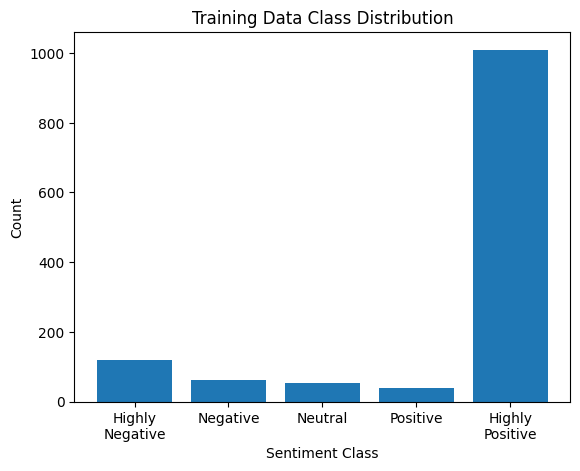

Video input shape: torch.Size([32, 50, 35])
Labels shape: torch.Size([32])
Labels after conversion shape: torch.Size([32])
Labels sample: tensor([4, 0, 4, 4, 3])
Model output shape: torch.Size([32, 5])
Epoch 1/50, Train Loss: 1.6250, Val Loss: 1.4902, Train Acc: 16.21%, Val Acc: 65.42%
Epoch 2/50, Train Loss: 1.2837, Val Loss: 0.9853, Train Acc: 76.38%, Val Acc: 76.17%
Epoch 3/50, Train Loss: 0.9418, Val Loss: 0.9039, Train Acc: 78.72%, Val Acc: 76.17%
Epoch 4/50, Train Loss: 0.9303, Val Loss: 0.8948, Train Acc: 78.72%, Val Acc: 76.17%
Epoch 5/50, Train Loss: 0.9157, Val Loss: 0.8917, Train Acc: 78.72%, Val Acc: 76.17%
Epoch 6/50, Train Loss: 0.8864, Val Loss: 0.8879, Train Acc: 78.72%, Val Acc: 76.17%
Epoch 7/50, Train Loss: 0.8622, Val Loss: 0.8843, Train Acc: 78.72%, Val Acc: 76.17%
Epoch 8/50, Train Loss: 0.8337, Val Loss: 0.8831, Train Acc: 78.72%, Val Acc: 76.17%
Epoch 9/50, Train Loss: 0.8374, Val Loss: 0.8814, Train Acc: 78.72%, Val Acc: 76.17%
Epoch 10/50, Train Loss: 0.8344, 

h:\Programs\Anaconda\envs\multimodal\lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


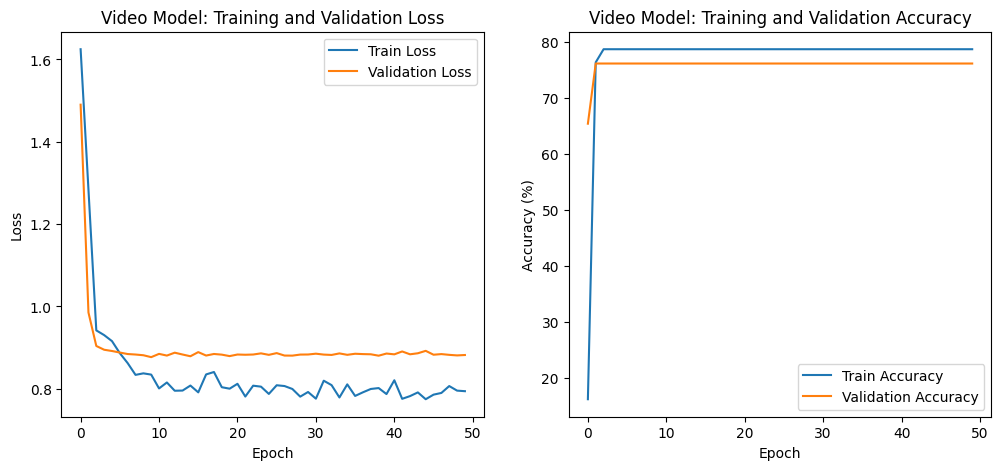

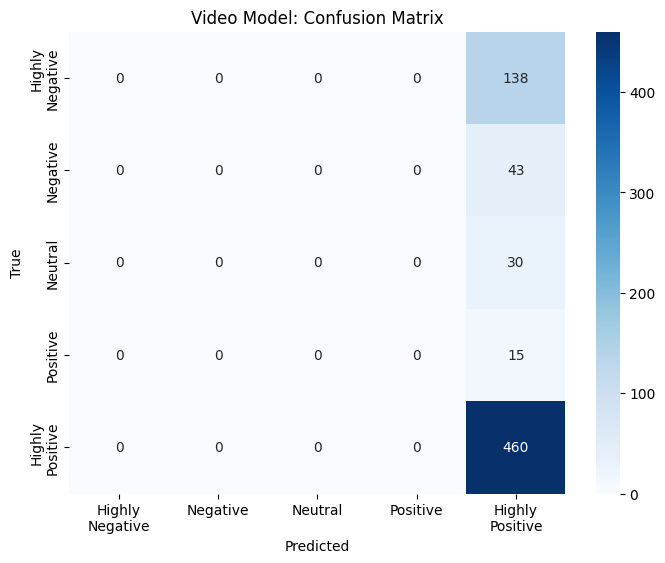

Video Model Test Accuracy: 0.6706


In [1]:
import os
os.chdir('MultiBench')
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
import seaborn as sns
from datasets.affect.get_data import get_dataloader

# Load the data
traindata, validdata, testdata = get_dataloader(
    'data/mosi_raw.pkl', robust_test=False, max_pad=True, data_type='mosi', max_seq_len=50, num_workers=0)

# Check video data dimensions
print("Training video data shape:", traindata.dataset.dataset['vision'].shape)
print("Validation video data shape:", validdata.dataset.dataset['vision'].shape)
print("Test video data shape:", testdata.dataset.dataset['vision'].shape)

# Let's check a sample batch to understand the data structure
for batch in traindata:
    print("Batch structure:")
    print(f"Video shape: {batch[0].shape}")
    print(f"Audio shape: {batch[1].shape}")
    print(f"Text shape: {batch[2].shape}")
    print(f"Labels shape: {batch[3].shape}")
    print(f"Labels sample: {batch[3][:5]}")
    break

# Convert continuous labels to 5 classes as mentioned in the paper
def convert_to_5class(labels):
    """Convert 7-point scale to 5-point scale as mentioned in the paper"""
    # Mapping: [-3,-2,-1,0,1,2,3] to [0,1,2,3,4]
    # Highly negative: -3,-2 -> 0
    # Negative: -1 -> 1
    # Neutral: 0 -> 2
    # Positive: 1 -> 3
    # Highly positive: 2,3 -> 4
    converted = []
    for label in labels:
        if label <= -2:
            converted.append(0)  # Highly negative
        elif label == -1:
            converted.append(1)  # Negative
        elif label == 0:
            converted.append(2)  # Neutral
        elif label == 1:
            converted.append(3)  # Positive
        else:  # label >= 2
            converted.append(4)  # Highly positive
    return np.array(converted)

# Analyze label distribution
train_labels = traindata.dataset.dataset['labels']
train_5class = convert_to_5class(train_labels)
class_counts = Counter(train_5class)
print("Class distribution:", class_counts)

# Plot class distribution
plt.bar(class_counts.keys(), class_counts.values())
plt.xlabel('Sentiment Class')
plt.ylabel('Count')
plt.title('Training Data Class Distribution')
plt.xticks([0,1,2,3,4], ['Highly\nNegative', 'Negative', 'Neutral', 'Positive', 'Highly\nPositive'])
plt.show()

class VideoUnimodalModel(nn.Module):
    def __init__(self, input_dim=35, hidden_dims=[32, 32, 32], output_dim=5):
        """
        Video Unimodal Model according to the paper's Visual Embedding Subnetwork.
        
        Args:
            input_dim: Dimension of visual features (35 for CMU-MOSI)
            hidden_dims: List of hidden layer dimensions [32, 32, 32] as per paper
            output_dim: Number of output classes (5 for sentiment classification)
        """
        super(VideoUnimodalModel, self).__init__()
        
        # Three hidden layers with 32 ReLU units each as described in the paper
        self.fc1 = nn.Linear(input_dim, hidden_dims[0])
        self.fc2 = nn.Linear(hidden_dims[0], hidden_dims[1])
        self.fc3 = nn.Linear(hidden_dims[1], hidden_dims[2])
        self.relu = nn.ReLU()
        
        # Output layer for 5-class classification
        self.output = nn.Linear(hidden_dims[2], output_dim)
        
        # Dropout for regularization (as mentioned in the paper)
        self.dropout = nn.Dropout(p=0.15)
        
    def forward(self, x):
        # Check if input needs to be flattened or processed differently
        # If x has shape [batch_size, seq_len, features], we need to handle it
        if x.dim() == 3:
            # Apply mean pooling across sequence length as mentioned in the paper
            x = torch.mean(x, dim=1)  # [batch_size, features]
        
        # Pass through three hidden layers with ReLU activation
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.relu(self.fc2(x))
        x = self.dropout(x)
        x = self.relu(self.fc3(x))
        x = self.dropout(x)
        
        # Output layer
        output = self.output(x)
        return output

def train_video_model(model, train_loader, val_loader, num_epochs=50, learning_rate=5e-4):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=0.01)  # L2 regularization as per paper
    
    train_losses = []
    val_losses = []
    train_accuracies = []
    val_accuracies = []
    
    for epoch in range(num_epochs):
        # Training phase
        model.train()
        train_loss = 0.0
        train_correct = 0
        train_total = 0
        
        for batch_idx, batch in enumerate(train_loader):
            # Extract video data and labels
            video = batch[0]  # Video is the first element
            labels = batch[3].squeeze()  # Labels are the fourth element
            
            # Debug: Print shapes
            if batch_idx == 0 and epoch == 0:
                print(f"Video input shape: {video.shape}")
                print(f"Labels shape: {labels.shape}")
            
            # Convert to 5-class labels
            labels_5class = convert_to_5class(labels.numpy())
            labels_5class = torch.tensor(labels_5class, dtype=torch.long)
            
            # Ensure labels are 1D
            if labels_5class.dim() > 1:
                labels_5class = labels_5class.squeeze()
            
            # Debug: Print shapes after conversion
            if batch_idx == 0 and epoch == 0:
                print(f"Labels after conversion shape: {labels_5class.shape}")
                print(f"Labels sample: {labels_5class[:5]}")
            
            optimizer.zero_grad()
            outputs = model(video)
            
            # Debug: Print model output shape
            if batch_idx == 0 and epoch == 0:
                print(f"Model output shape: {outputs.shape}")
            
            loss = criterion(outputs, labels_5class)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            train_total += labels_5class.size(0)
            train_correct += (predicted == labels_5class).sum().item()
        
        # Validation phase
        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0
        
        with torch.no_grad():
            for batch in val_loader:
                video = batch[0]
                labels = batch[3].squeeze()
                
                labels_5class = convert_to_5class(labels.numpy())
                labels_5class = torch.tensor(labels_5class, dtype=torch.long)
                
                # Ensure labels are 1D
                if labels_5class.dim() > 1:
                    labels_5class = labels_5class.squeeze()
                
                outputs = model(video)
                loss = criterion(outputs, labels_5class)
                
                val_loss += loss.item()
                _, predicted = torch.max(outputs.data, 1)
                val_total += labels_5class.size(0)
                val_correct += (predicted == labels_5class).sum().item()
        
        # Calculate metrics
        train_loss_avg = train_loss / len(train_loader)
        val_loss_avg = val_loss / len(val_loader)
        train_acc = 100 * train_correct / train_total
        val_acc = 100 * val_correct / val_total
        
        train_losses.append(train_loss_avg)
        val_losses.append(val_loss_avg)
        train_accuracies.append(train_acc)
        val_accuracies.append(val_acc)
        
        print(f'Epoch {epoch+1}/{num_epochs}, '
              f'Train Loss: {train_loss_avg:.4f}, Val Loss: {val_loss_avg:.4f}, '
              f'Train Acc: {train_acc:.2f}%, Val Acc: {val_acc:.2f}%')
    
    return model, train_losses, val_losses, train_accuracies, val_accuracies

def evaluate_video_model(model, test_loader):
    model.eval()
    all_predictions = []
    all_labels = []
    
    with torch.no_grad():
        for batch in test_loader:
            video = batch[0]
            labels = batch[3].squeeze()
            
            labels_5class = convert_to_5class(labels.numpy())
            
            outputs = model(video)
            _, predicted = torch.max(outputs.data, 1)
            
            all_predictions.extend(predicted.cpu().numpy())
            all_labels.extend(labels_5class)
    
    # Calculate metrics
    accuracy = accuracy_score(all_labels, all_predictions)
    precision, recall, f1, _ = precision_recall_fscore_support(
        all_labels, all_predictions, average='weighted')
    
    # Confusion matrix
    cm = confusion_matrix(all_labels, all_predictions)
    
    return accuracy, precision, recall, f1, cm

def plot_video_results(train_losses, val_losses, train_accuracies, val_accuracies, cm):
    # Plot loss curves
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(train_losses, label='Train Loss')
    plt.plot(val_losses, label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Video Model: Training and Validation Loss')
    plt.legend()
    
    # Plot accuracy curves
    plt.subplot(1, 2, 2)
    plt.plot(train_accuracies, label='Train Accuracy')
    plt.plot(val_accuracies, label='Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy (%)')
    plt.title('Video Model: Training and Validation Accuracy')
    plt.legend()
    plt.show()
    
    # Plot confusion matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Highly\nNegative', 'Negative', 'Neutral', 'Positive', 'Highly\nPositive'],
                yticklabels=['Highly\nNegative', 'Negative', 'Neutral', 'Positive', 'Highly\nPositive'])
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Video Model: Confusion Matrix')
    plt.show()

def get_video_test_accuracy(model, test_loader):
    """
    Simple function to get just the test accuracy for video model.
    
    Args:
        model: Trained video model
        test_loader: Test data loader
    
    Returns:
        float: Test accuracy
    """
    model.eval()
    all_predictions = []
    all_labels = []
    
    with torch.no_grad():
        for batch in test_loader:
            video = batch[0]
            labels = batch[3].squeeze()
            
            labels_5class = convert_to_5class(labels.numpy())
            
            outputs = model(video)
            _, predicted = torch.max(outputs.data, 1)
            
            all_predictions.extend(predicted.cpu().numpy())
            all_labels.extend(labels_5class)
    
    # Calculate accuracy
    accuracy = accuracy_score(all_labels, all_predictions)
    return accuracy

# Initialize the video model
video_model = VideoUnimodalModel()

# Train the video model
trained_video_model, video_train_losses, video_val_losses, video_train_accuracies, video_val_accuracies = train_video_model(
    video_model, traindata, validdata, num_epochs=50)

# Evaluate on test set
video_test_accuracy, video_test_precision, video_test_recall, video_test_f1, video_cm = evaluate_video_model(
    trained_video_model, testdata)

print(f'Video Model Test Accuracy: {video_test_accuracy:.4f}')
print(f'Video Model Test Precision: {video_test_precision:.4f}')
print(f'Video Model Test Recall: {video_test_recall:.4f}')
print(f'Video Model Test F1 Score: {video_test_f1:.4f}')

# Plot results
plot_video_results(video_train_losses, video_val_losses, video_train_accuracies, video_val_accuracies, video_cm)

# Get just the test accuracy
video_test_accuracy = get_video_test_accuracy(trained_video_model, testdata)
print(f'Video Model Test Accuracy: {video_test_accuracy:.4f}')
